# 🏨 Hotel Cancellation Prediction: Logistic Regression Lab
## Can we predict which bookings will be cancelled before they happen?

---

### The Business Problem

Hotel cancellations are a massive headache for the hospitality industry.  
Consider a hotel with 200 rooms that is fully booked for a Saturday night:

- If **20% of bookings cancel** (a realistic figure), the hotel loses revenue on 40 rooms it could have re-sold.
- If the hotel **overbooks aggressively** and fewer people cancel than expected, it must walk guests to a competitor — destroying customer loyalty.
- You are a data scientist at a fast growing hotel brand and they need a better way to predict cancellations, they have a pretty good size
dataset and would like you to help. If the model works well you get a 10% bonus of all the recovered revenue!  

**A good cancellation-prediction model lets hotels:**
1. **Optimize overbooking** — sell the right number of extra rooms so the hotel fills up even after cancellations.
2.  **Improve staffing** — if 30% of tonight's bookings will cancel, fewer housekeepers and front-desk staff are needed.
3.  **Target at-risk bookings** — reach out proactively with incentives (free breakfast, discount upgrade) to guests who are likely to cancel.

### The Dataset

We are working with the **Hotel Booking Demand** dataset (~119 k real bookings from two Portuguese hotels).  
Our **target variable** is `is_canceled`: `1` if the booking was cancelled, `0` if the guest actually showed up.

### What You Will Build

| Model | Key idea |
|-------|----------|
| **Model 1** | Baseline pipeline — default solver (`lbfgs`), one-hot encoding + standard scaling |
| **Model 2** | Solver exploration — try using different solvers and see if the model improves |
| **Model 3** | Class-weighted logistic regression + cross-validation to handle imbalanced labels |



---
## 1 · Setup & Data Loading

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)

from sklearn.calibration import CalibratedClassifierCV

sns.set_style('whitegrid')

In [28]:
df = pd.read_csv('hotels.csv')


---
## 2 · Exploratory Data Analysis

Before building any model we need to **understand our data**.  


In [29]:
# Summary stats and basic info
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


Cancellation rate: 0.37
is_canceled
0    75166
1    44224
Name: count, dtype: int64


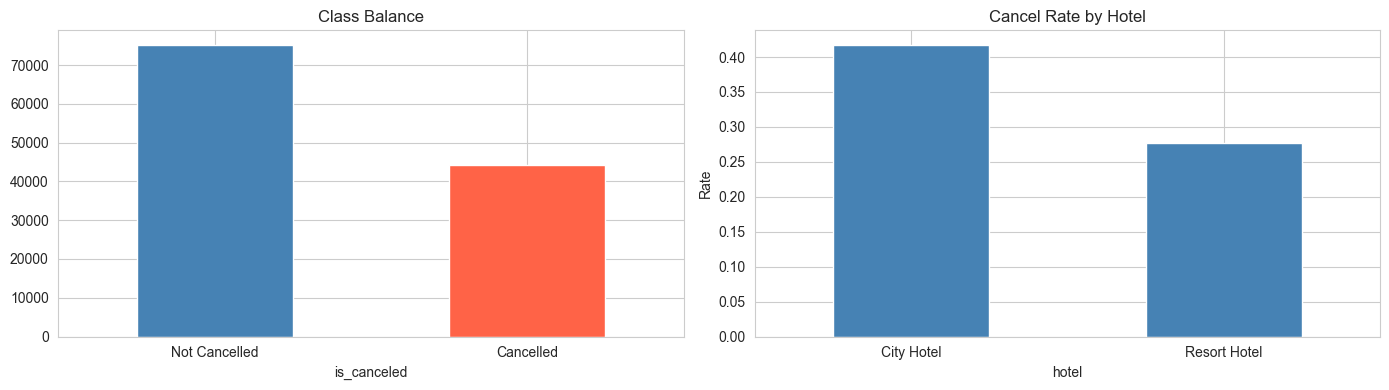

In [30]:
# Basic EDA
print("Cancellation rate:", df['is_canceled'].mean().round(3))
print(df['is_canceled'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class balance
df['is_canceled'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Class Balance')
axes[0].set_xticklabels(['Not Cancelled', 'Cancelled'], rotation=0)

# Cancellation rate by hotel type
df.groupby('hotel')['is_canceled'].mean().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Cancel Rate by Hotel')
axes[1].set_ylabel('Rate')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


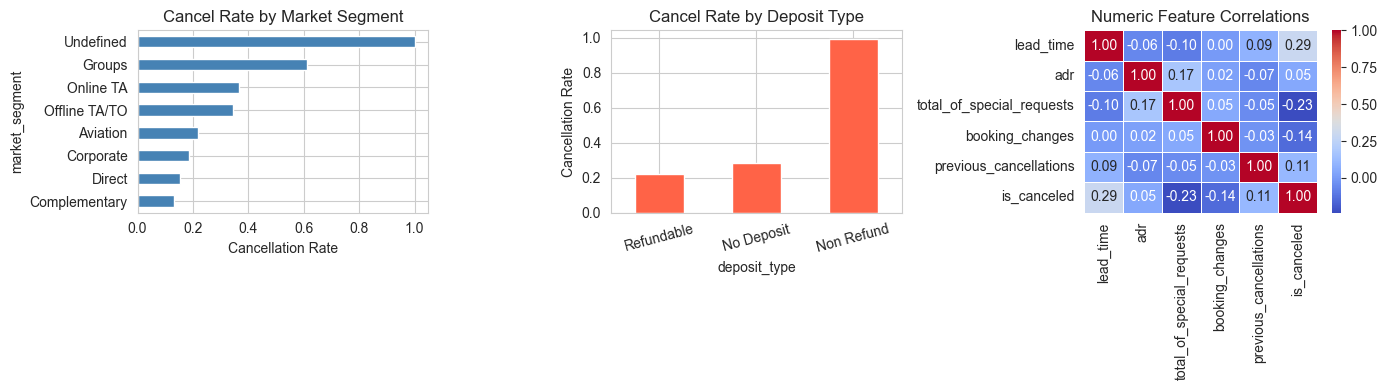

In [31]:
# More EDA
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Cancellation rate by market segment
df.groupby('market_segment')['is_canceled'].mean().sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Cancel Rate by Market Segment')
axes[0].set_xlabel('Cancellation Rate')

# Cancellation rate by deposit type
df.groupby('deposit_type')['is_canceled'].mean().sort_values().plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Cancel Rate by Deposit Type')
axes[1].set_ylabel('Cancellation Rate')
axes[1].tick_params(axis='x', rotation=15)

# Correlation heatmap of numeric features
num_cols = ['lead_time', 'adr', 'total_of_special_requests','booking_changes', 'previous_cancellations', 'is_canceled']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2], linewidths=0.5)
axes[2].set_title('Numeric Feature Correlations')

plt.tight_layout()
plt.show()


---
## 3 · Feature Engineering - Preparation

Before building any model we need to **understand our data**. 

In [32]:
# Check for missing data and drop features with too many missing values, there are some. 
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [33]:

# based on this output we can drop agent and company since they have lots of missing values and likely won't be useful for our model.
# Ill also choose to drop country since is also has missing values and we have other features that capture similar information (like market segment).

df = df.drop(columns=['agent', 'company', 'country'])
df = df.fillna(0)  # Fill remaining missing values with 0 

In [34]:
# There are two other features that need to be dropped because they  directly leak the target variable.
# Another way to say this is they represent leakage in the dataset.

# the two features that leak the target variable are reservation_status and reservation_status_date.
# reservation_status is the current status of the reservation, which is either 'Canceled', 'Checked-Out', or 'No-Show'. This directly indicates whether the reservation was canceled or not, so it leaks the target variable.
# reservation_status_date is the date when the reservation status was last updated. This also leaks the target variable because if the reservation was canceled, the reservation_status_date would indicate when the cancellation occurred.
df = df.drop(columns=['reservation_status', 'reservation_status_date'])

---
### Feature groups, see step 4 in the example (i think it goes 1,2,4 I deleted 3 and didn't change the numbering)

Create lists for the **numerical** and **categorical** so we can apply the right transformations to each group inside a `ColumnTransformer`.

> **Why scale numerics?** Logistic regression uses gradient descent internally.  
> Features on very different scales (e.g. `lead_time` 0–737 vs `adults` 0–4) slow convergence.  
> `StandardScaler` fixes this by converting each feature to mean=0, std=1.

> **Why one-hot encode categoricals?** Logistic regression can't handle strings.  
> One-hot encoding converts each category into its own binary (0/1) column.

Keep in mind that we want to use the pipeline package to handle this preprocessing so create lists of names of numeric and category then pass them into the pipeline, not necessarily creating different dataframes. 



In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [36]:
# Prepare for the pipeline make sure to do so for both **numerical** and **categorical**. 
# Generate dataframe for the features and target variable, X and y.
CATEGORICAL = ['hotel','arrival_date_month','meal','market_segment','distribution_channel','reserved_room_type','assigned_room_type','deposit_type','customer_type']
NUMERIC     = ['lead_time','arrival_date_year','arrival_date_week_number','arrival_date_day_of_month','stays_in_weekend_nights','stays_in_week_nights',
               'adults','children','babies','is_repeated_guest','previous_cancellations','previous_bookings_not_canceled','booking_changes','days_in_waiting_list',
               'adr','required_car_parking_spaces','total_of_special_requests']
TARGET      = 'is_canceled'

X = df[CATEGORICAL + NUMERIC]
y = df[TARGET]



In [37]:
# Train / test split — 80/20, stratified so class ratios are preserved 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

percent_positive_train = y_train.mean() * 100
print(f"Train positive class: {percent_positive_train:.2f}%")

percent_positive_test = y_test.mean() * 100
print(f"Test positive class: {percent_positive_test:.2f}%")

Train: 95512 rows | Test: 23878 rows
Train positive class: 37.04%
Test positive class: 37.04%


---
## 4 · Model Building and Evaluation

Now we are going to build our **model pipeline** and use the transformers

---
Model 1 — Baseline Logistic Regression

Our first pipeline is intentionally **simple**.  
The goal is to establish a baseline score we can try to beat later.
Transformer categorical using one-hot encoding and numerical using the MinMaxscaler()

X_raw  →  ColumnTransformer  →  LogisticRegression(solver='lbfgs')
           (scale + encode)


**`lbfgs`** (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is sklearn's default solver, like we talked about in class

---
 Model 1 Evaluation: Now that the model is build lets evaluate the model using confusion matrix and ROC/AUC. Give the goal of your assignment how well does the model work?

The Confusion Matrix Will Be Important Evaluation Tool

For a hotel-cancellation problem the four cells of the confusion matrix have real business meaning:

| | Predicted: Kept | Predicted: Cancelled |
|---|---|---|
| **Actual: Kept** |  **True Negative (TN)** — correctly identified loyal guest |  **False Positive (FP)** — wrongly flagged a loyal guest as a canceller |
| **Actual: Cancelled** |  **False Negative (FN)** — missed a cancellation (costly!) |  **True Positive (TP)** — correctly predicted a cancellation |

**Business impact:**
- **False Negatives** are expensive — we didn't anticipate the cancellation, so we can't fill the room.
- **False Positives** are annoying but cheaper — we might over-staff or over-book slightly.

In [38]:
# Build our first pipeline!

# First start with Preprocessing. 
preprocessor_m1 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) # numerics passed through unchanged
])

# Now build the pipeline by combining the preprocessor with a model.
pipe_m1 = Pipeline(steps=[
    ('prep',  preprocessor_m1),
    ('model', LogisticRegression(solver='lbfgs', max_iter=5000, random_state=42, n_jobs=-1))
])

# fit the pipeline to the training data
pipe_m1.fit(X_train, y_train)

/Users/joshdetatuva/Linear Regression Lab/week_8/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

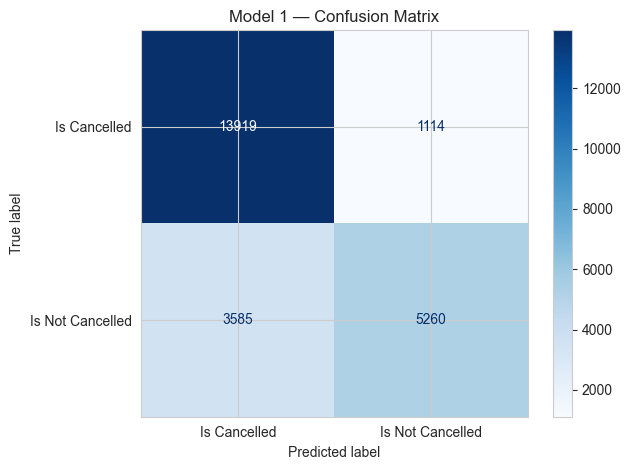

                  precision    recall  f1-score   support

    Is Cancelled       0.80      0.93      0.86     15033
Is Not Cancelled       0.83      0.59      0.69      8845

        accuracy                           0.80     23878
       macro avg       0.81      0.76      0.77     23878
    weighted avg       0.81      0.80      0.79     23878



In [39]:
# Now we can look at the results
y_pred_m1 = pipe_m1.predict(X_test)
cm_m1 = confusion_matrix(y_test, y_pred_m1)
disp_m1 = ConfusionMatrixDisplay(confusion_matrix=cm_m1, display_labels=['Is Cancelled', 'Is Not Cancelled'])
disp_m1.plot(cmap='Blues')
plt.title('Model 1 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_m1, target_names=['Is Cancelled', 'Is Not Cancelled']))

#### Interpreting 


Is Cancelled:
- When the model predicts Cancelled, it will be right 80% of the time. 
- The model catches 93% of all actual cancellations. 
Is not Cancelled:
- When the model predicts is not Cancelled, it will be right 83% of the time. 
- The model catches 59% of actual non Cancellations. 

This means that those 3585 false positives are guests the model predicts will cancel, but they actually show up. This could cost the hotel to lose money with overbooking. 

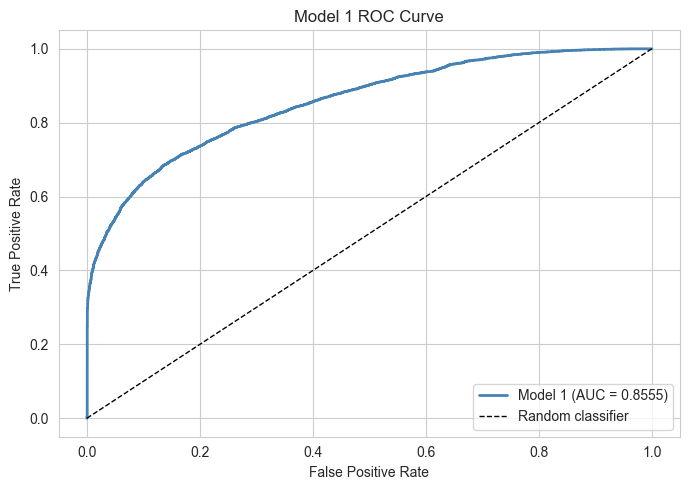

Model 1 ROC-AUC: 0.8555


In [40]:
y_proba_m1 = pipe_m1.predict_proba(X_test)[:, 1]
fpr_m1, tpr_m1, thresholds = roc_curve(y_test, y_proba_m1)
auc_m1 = roc_auc_score(y_test, y_proba_m1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m1, tpr_m1, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc_m1:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 1 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc_m1:.4f}")

---
## 5 · Model 2 — Exploring Different Solvers 

- Adjust your model object in the pipeline then evaluate again using confusion matrix and ROC/AUC. Make sure to eval on the test set. You should create a model_2_pipe, use much of the same code but create a new pipeline for each model

Sklearn's `LogisticRegression` supports several **solvers** (optimisation algorithms) and  
**regularisation strategies** controlled by `l1_ratio` and `C`.

| Solver | Best for |
|--------|----------|
| `lbfgs` | Default; works well on most datasets (L2 regularisation) |
| `liblinear` | Smaller datasets; supports L1 via `l1_ratio=1` |
| `saga` | Large datasets; supports L1, L2, and ElasticNet |


Did the model improve based on the various solvers?



### Liblinear solver first

In [41]:
# Train / test split — 80/20, stratified so class ratios are preserved 
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

In [42]:
preprocessor_m2 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) # numerics passed through unchanged
])

# Now build the pipeline by combining the preprocessor with a model.
pipe_m2_liblinear = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(solver='liblinear', max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m2_liblinear.fit(X2_train, y2_train)

/Users/joshdetatuva/Linear Regression Lab/week_8/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

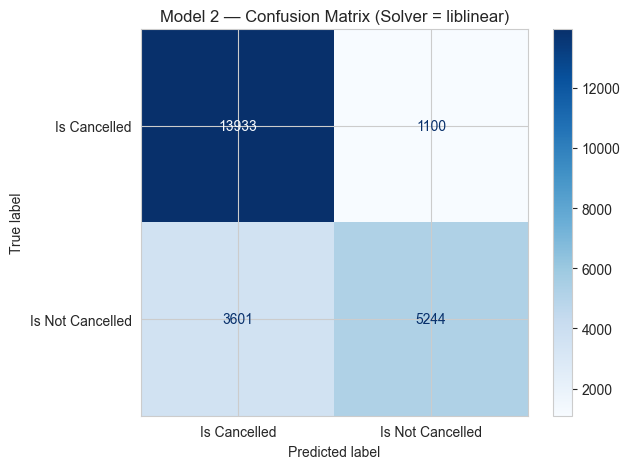

                  precision    recall  f1-score   support

    Is Cancelled       0.79      0.93      0.86     15033
Is Not Cancelled       0.83      0.59      0.69      8845

        accuracy                           0.80     23878
       macro avg       0.81      0.76      0.77     23878
    weighted avg       0.81      0.80      0.79     23878



In [43]:
# Now we can look at the results
y_pred_m2 = pipe_m2_liblinear.predict(X2_test)
cm_m2 = confusion_matrix(y2_test, y_pred_m2)
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['Is Cancelled', 'Is Not Cancelled'])
disp_m2.plot(cmap='Blues')
plt.title('Model 2 — Confusion Matrix (Solver = liblinear)')
plt.tight_layout()
plt.show()

print(classification_report(y2_test, y_pred_m2, target_names=['Is Cancelled', 'Is Not Cancelled']))

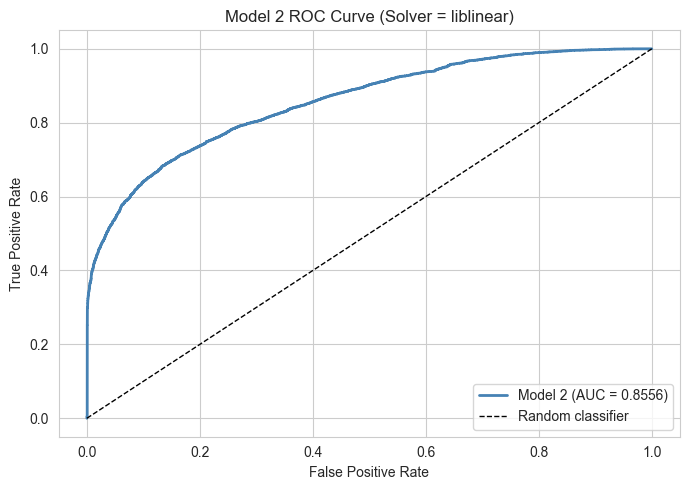

Model 2 ROC-AUC: 0.8556


In [44]:
y_proba_m2 = pipe_m2_liblinear.predict_proba(X2_test)[:, 1]
fpr_m2, tpr_m2, thresholds = roc_curve(y2_test, y_proba_m2)
auc_m2 = roc_auc_score(y2_test, y_proba_m2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m2, tpr_m2, lw=2, color='steelblue', label=f'Model 2 (AUC = {auc_m2:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 ROC Curve (Solver = liblinear)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 ROC-AUC: {auc_m2:.4f}")

### Now lets try Saga Solver

In [45]:
preprocessor_m2 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) # numerics passed through unchanged
])

# Now build the pipeline by combining the preprocessor with a model.
pipe_m2_saga = Pipeline(steps=[
    ('prep',  preprocessor_m2),
    ('model', LogisticRegression(solver='saga', penalty='elasticnet', l1_ratio=0.5,max_iter=5000, random_state=42, n_jobs=-1))
])

pipe_m2_saga.fit(X2_train, y2_train)

/Users/joshdetatuva/Linear Regression Lab/week_8/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/joshdetatuva/Linear Regression Lab/week_8/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

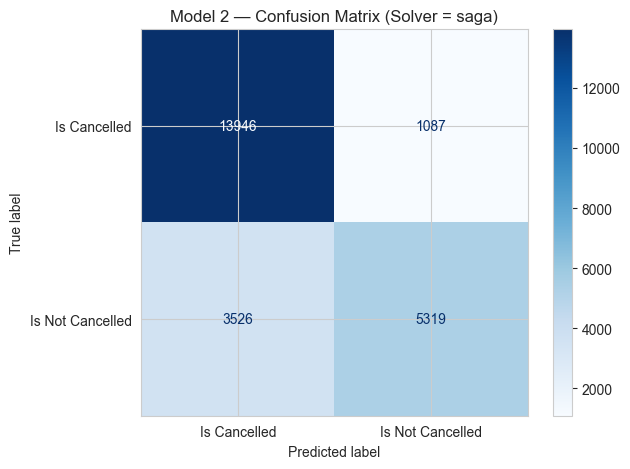

                  precision    recall  f1-score   support

    Is Cancelled       0.80      0.93      0.86     15033
Is Not Cancelled       0.83      0.60      0.70      8845

        accuracy                           0.81     23878
       macro avg       0.81      0.76      0.78     23878
    weighted avg       0.81      0.81      0.80     23878



In [46]:
# Now we can look at the results
y_pred_m2 = pipe_m2_saga.predict(X2_test)
cm_m2 = confusion_matrix(y2_test, y_pred_m2)
disp_m2 = ConfusionMatrixDisplay(confusion_matrix=cm_m2, display_labels=['Is Cancelled', 'Is Not Cancelled'])
disp_m2.plot(cmap='Blues')
plt.title('Model 2 — Confusion Matrix (Solver = saga)')
plt.tight_layout()
plt.show()

print(classification_report(y2_test, y_pred_m2, target_names=['Is Cancelled', 'Is Not Cancelled']))

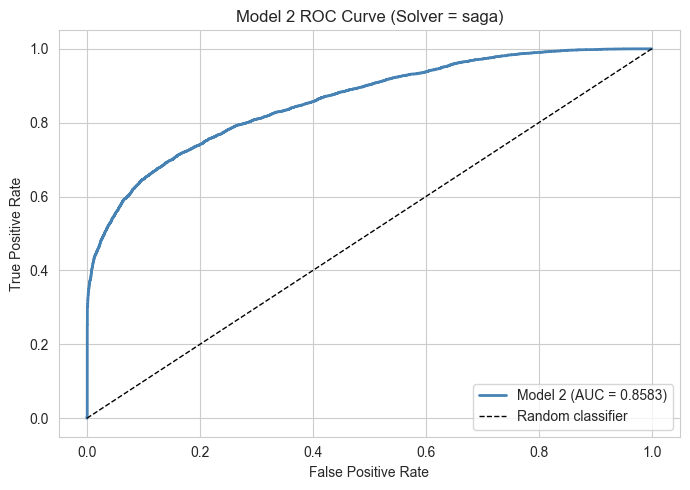

Model 2 ROC-AUC: 0.8583


In [47]:
y_proba_m2 = pipe_m2_saga.predict_proba(X2_test)[:, 1]
fpr_m2, tpr_m2, thresholds = roc_curve(y2_test, y_proba_m2)
auc_m2 = roc_auc_score(y2_test, y_proba_m2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m2, tpr_m2, lw=2, color='steelblue', label=f'Model 2 (AUC = {auc_m2:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 2 ROC Curve (Solver = saga)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 2 ROC-AUC: {auc_m2:.4f}")

## Did the model improve based on the various solvers?

Switching solvers produced negligible differences in performance. 
Liblinear (L1) moved ROC-AUC from 0.8555 → 0.8556, and Saga 
(ElasticNet) from 0.8555 → 0.8583 this means that both 
not meaningfully better than the baseline.

---
## 6 · Model 3 — Balanced Class Weights + Cross-Validation

Build a final model (pipe_3) with a balanced class weight and use cross validation. As a reminder cv happens on the fit process not as part of the pipeline and we need to build our CV object, similar to the model object. . 

Use the example shown in class to see how to apply cross validation, balanced weight is a argument in the logreg function that you just need to apply as seen below. 

### The Class Imbalance Problem

Our dataset has ~63% non-cancellations and ~37% cancellations.  
A lazy model could achieve 63% accuracy by *always* predicting "Kept"!  
We saw that Models 1 and 2 sometimes struggled with **recall on the cancelled class**.

### Solution: `class_weight='balanced'`

Setting `class_weight='balanced'` tells sklearn to automatically weight the training samples  
so that the minority class (cancellations) gets more attention during training.

Specifically, each class gets weight = `n_samples / (n_classes × n_samples_in_class)`.

### Solution: Cross-Validation

Instead of a single train/test split (which can be lucky or unlucky),  
**k-fold cross-validation** trains and evaluates the model on `k` different splits  
and reports the average — giving a much more reliable estimate of real-world performance.

```
Fold 1: [train | train | train | train | VAL ]
Fold 2: [train | train | train | VAL  | train]
Fold 3: [train | train | VAL  | train | train]
...and so on
```

---

### Experiments

- Change the number of folds from `5` to `10` — does the mean AUC change much? 
 **No the AUC didn't change much at all it was a very marginal change. The run time has increased significantly as a result however.**
- Try removing `class_weight='balanced'` — what happens to recall on the cancelled class? 
**The recall for Is Cancelled went up my one point and the recall for Is Not Cancelled went down by one point.**

## Building Model 3 with Cross validation and Balanced Class weights blow. 

In [48]:
# Split the data again to reset the random state and ensure a fair comparison between the two models.
# Train / test split — 80/20, stratified so class ratios are preserved 
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

In [49]:
# SGDClassifier with log-loss == logistic regression optimized via SGD
sgd_lr = SGDClassifier(
    loss='log_loss',
    penalty='l2',
    alpha=0.01,  # regularization strength
    max_iter=5000,
    random_state=42,
    class_weight='balanced'  
)

preprocessor_m3 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', StandardScaler(), NUMERIC)
])

base_pipe = Pipeline(steps=[
    ('prep',  preprocessor_m3),
    ('model', sgd_lr)
])

# Isotonic calibration — learns a monotone mapping from raw scores to probabilities
pipe_m3 = CalibratedClassifierCV(base_pipe, method='isotonic', cv=5)
pipe_m3.fit(X3_train, y3_train)
print("Model 3 (calibrated SGD) fitted.")

Model 3 (calibrated SGD) fitted.


## 5-Fold Stratified Cross-Validation without calibration.  

5-Fold Cross-Validation Results (SGD Logistic Regression):
  ROC-AUC : 0.8113  ± 0.0022  | folds: [0.8097 0.8079 0.8122 0.8122 0.8144]
  F1      : 0.6655  ± 0.0039  | folds: [0.6629 0.6591 0.6684 0.6677 0.6695]


/var/folders/gt/shnmlhhs6wj9410vy0ykb1vh0000gn/T/ipykernel_91900/1160787752.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,


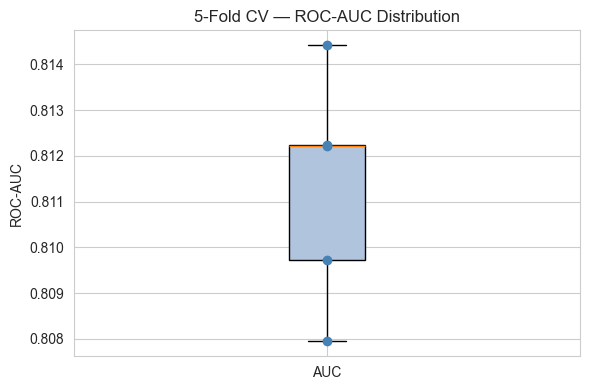

In [50]:
# Build the new pipeline with the same preprocessing but a different model. 
# We will use Stochastic Gradient Descent (SGD) classifier, which is a linear model that can be used with different loss functions and penalties.
pipe_3 = Pipeline(steps=[
    ('prep',  ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
        ('num', MinMaxScaler(), NUMERIC)
    ])),
    ('model', SGDClassifier(loss='log_loss', penalty='l2', alpha=0.01,
                            max_iter=1000, random_state=42, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc  = cross_val_score(pipe_3, X, y, cv=cv, scoring='roc_auc')
cv_f1   = cross_val_score(pipe_3, X, y, cv=cv, scoring='f1')

print("5-Fold Cross-Validation Results (SGD Logistic Regression):")
print(f"  ROC-AUC : {cv_auc.mean():.4f}  ± {cv_auc.std():.4f}  | folds: {np.round(cv_auc, 4)}")
print(f"  F1      : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}  | folds: {np.round(cv_f1, 4)}")

# Box-plot of fold AUCs
fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot([cv_auc], labels=['AUC'], patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.scatter([1]*5, cv_auc, color='steelblue', zorder=3)
ax.set_title('5-Fold CV — ROC-AUC Distribution')
ax.set_ylabel('ROC-AUC')
plt.tight_layout()
plt.show()


## Model 3 Evaluation 

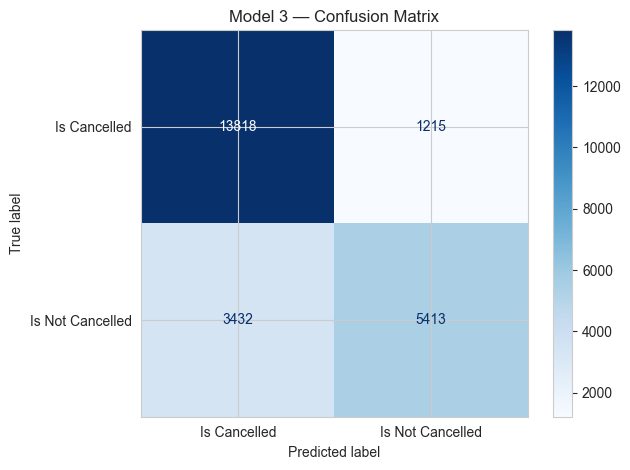

                  precision    recall  f1-score   support

    Is Cancelled       0.80      0.92      0.86     15033
Is Not Cancelled       0.82      0.61      0.70      8845

        accuracy                           0.81     23878
       macro avg       0.81      0.77      0.78     23878
    weighted avg       0.81      0.81      0.80     23878



In [51]:
y_pred_m3 = pipe_m3.predict(X3_test)
cm_m3 = confusion_matrix(y3_test, y_pred_m3)
disp_m3 = ConfusionMatrixDisplay(confusion_matrix=cm_m3, display_labels=['Is Cancelled', 'Is Not Cancelled'])
disp_m3.plot(cmap='Blues')
plt.title('Model 3 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y3_test, y_pred_m3, target_names=['Is Cancelled', 'Is Not Cancelled']))

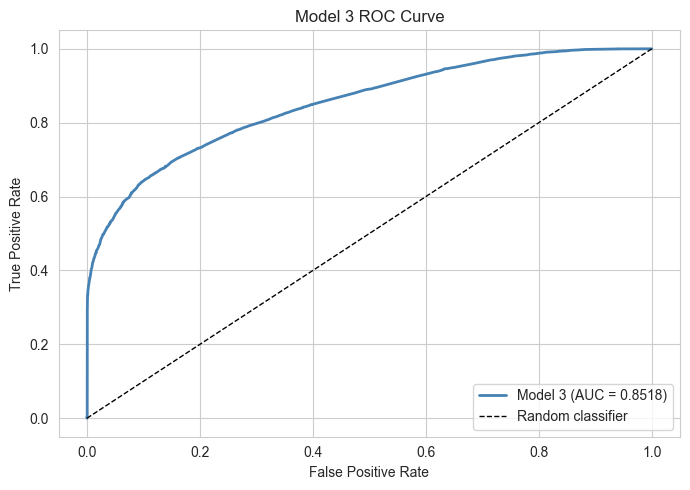

Model 3 ROC-AUC: 0.8518


In [52]:
y_proba_m3 = pipe_m3.predict_proba(X3_test)[:, 1]
fpr_m3, tpr_m3, thresholds_m3 = roc_curve(y3_test, y_proba_m3)
auc_m3 = roc_auc_score(y3_test, y_proba_m3)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m3, tpr_m3, lw=2, color='steelblue', label=f'Model 3 (AUC = {auc_m3:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 3 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 3 ROC-AUC: {auc_m3:.4f}")

---
## 07 · Summary & Reflection

### What We Learned

**Model Performance**
- Which model worked best and why do you think that is the case? Write a short recommendation to your boss on how to proceed (1 paragraph)

### Challenge Extensions - extra 5 points for each

If you want to push further:

1. **Tune `C`** using `GridSearchCV` over the range `[0.001, 0.01, 0.1, 1, 10, 100]`.
2. **Engineer new features** — e.g. `total_nights = stays_in_weekend_nights + stays_in_week_nights`.
3. **Try a different model** — replace `LogisticRegression` in the pipeline with `RandomForestClassifier` or `GradientBoostingClassifier`. Does AUC improve? or maybe kNN
4. **Interpret coefficients** — given that the variables have been standardized create a horizontal bar chart showing
the rankings of the coeficients 

---

### Which model worked best and why do you think that is the case?
Logistic Regression with the Saga solver and ElasticNet regularization performed best, achieving a ROC-AUC of 0.8583 and 81% accuracy, though the honest takeaway is that all four models performed nearly identically. The slight edge from ElasticNet likely comes from its ability to handle the correlated features in this dataset and its penalty parameters. This model is a good first step as it correctly identifies 93% of cancellations saving the hotel money or making them more money because we can target these customers on why they cancelled or send more promotions/notices. However, I would not recommend to rely on this regression model alone because it does poorly on the recall of non cancelled guests at only 59%-61%. That means that approximately 4/10 guests who have shown up are being flagged as likely cancelers. This can lead to a significant amount of false positives and guests who get overbooking pressure applied or retention offers sent unnecessarily. Put in a simpler way the model is trying to overly catch every cancellation at the cost of misclassifying the loyal guests that don't end up canceling. So my recommendation would to use this model as an initial prediction that we can use to consider sending pre arrival confirmation emails to high risk bookings. 

## Challenge Extensions -- Trying a different model. 

Ill be using RandomForestClassifier instead of Logistic Regression 



In [53]:
# import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

In [54]:
X4_train, X4_test, y4_train, y4_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

In [55]:

# Make preprocesesr 
preprocessor_m4 = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
    ('num', MinMaxScaler(), NUMERIC) # numerics passed through unchanged
])

# Now build the pipeline by combining the preprocessor with a model.
pipe_m4 = Pipeline(steps=[
    ('prep',  preprocessor_m4),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

# fit the pipeline to the training data
pipe_m4.fit(X4_train, y4_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

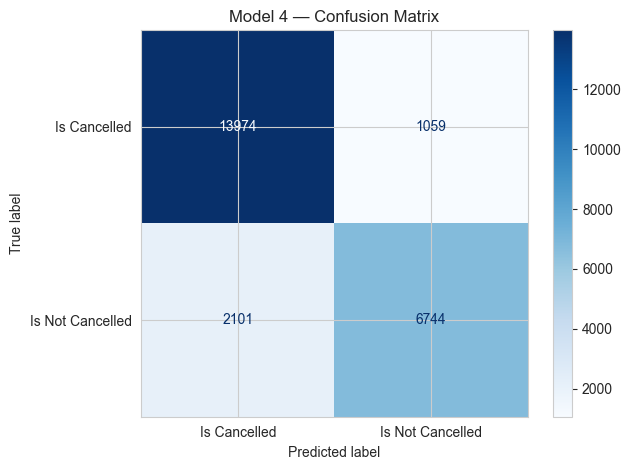

                  precision    recall  f1-score   support

    Is Cancelled       0.87      0.93      0.90     15033
Is Not Cancelled       0.86      0.76      0.81      8845

        accuracy                           0.87     23878
       macro avg       0.87      0.85      0.85     23878
    weighted avg       0.87      0.87      0.87     23878



In [56]:
y_pred_m4 = pipe_m4.predict(X4_test)
cm_m4 = confusion_matrix(y4_test, y_pred_m4)
disp_m4 = ConfusionMatrixDisplay(confusion_matrix=cm_m4, display_labels=['Is Cancelled', 'Is Not Cancelled'])
disp_m4.plot(cmap='Blues')
plt.title('Model 4 — Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y4_test, y_pred_m4, target_names=['Is Cancelled', 'Is Not Cancelled']))

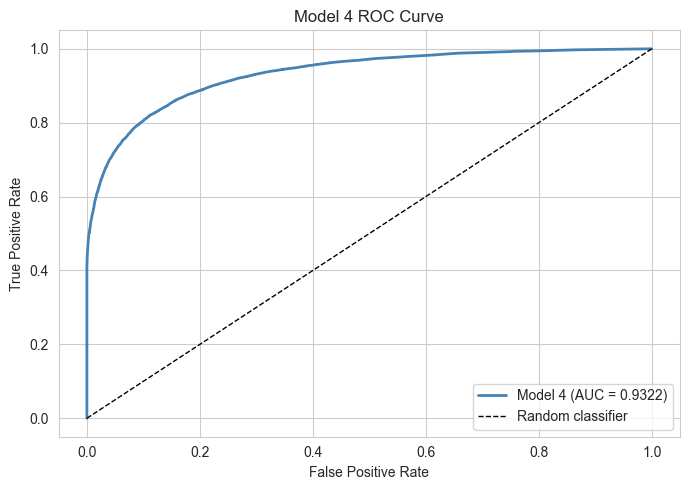

Model 4 ROC-AUC: 0.9322


In [57]:
y_proba_m4 = pipe_m4.predict_proba(X4_test)[:, 1]
fpr_m4, tpr_m4, thresholds_m4 = roc_curve(y4_test, y_proba_m4)
auc_m4 = roc_auc_score(y4_test, y_proba_m4)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_m4, tpr_m4, lw=2, color='steelblue', label=f'Model 4 (AUC = {auc_m4:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Model 4 ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 4 ROC-AUC: {auc_m4:.4f}")

## Results
The ROC-AUC score went up significantly. Using RandomForestClassifier also increased overall accuracy from 0.81 with logistic regression to 0.87. The biggest improvement was the Recall for Is Not Cancelled. It went from 0.59-0.61 with logistic regression to 0.76 with RandomForestClassifier. So this model would be a way better fit for this data. 